In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Please tell me how can i help you", name="LLMMode")]
messages.append(HumanMessage(content=f"I want to learn coding ",name="Bixby"))
messages.append(AIMessage(content=f"Please tell me which programming language do you want to learn", name="LLMMode"))
messages.append(AIMessage(content=f"I want to learn python programming language", name="Bixby"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: LLMMode

Please tell me how can i help you
================================ Human Message =================================
Name: Bixby

I want to learn coding 
================================== Ai Message ==================================
Name: LLMMode

Please tell me which programming language do you want to learn
================================== Ai Message ==================================
Name: Bixby

I want to learn python programming language


In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")
llm.invoke(messages)

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Great! Python is a fantastic first language—clear syntax, huge community, and tons of libraries for everything from web development to data science.\n\nLet’s start by narrowing down a few details so I can tailor the best learning path for you:\n\n1. **Experience Level**  \n   - Have you coded before (in any language)?  \n   - If yes, which languages and how comfortable are you with concepts like variables, loops, functions, and objects?\n\n2. **Goals & Interests**  \n   - What do you want to build with Python?  \n     - Web apps (Flask/Django)  \n     - Data analysis / machine learning (pandas, NumPy, scikit‑learn)  \n     - Automation / scripting (file handling, web scraping)  \n     - Game development (Pygame)  \n     - Something else?\n\n3. **Learning Style**  \n   - Do you prefer:\n     - Interactive tutorials (Codecademy, freeCodeCamp, Exercism)  \n     - Structured courses (Coursera, Udemy, edX)  \n     - Reading books (e.g., “Automate the Boring Stuff with Pyt

In [5]:
def add(a: int, b:int) -> int:
    """
    Adds two integers a and b
    
    Args: 
        a: first integer
        b: second integer
    
    Return:
        int

    """
    return a+b

In [7]:
llm_with_tool = llm.bind_tools([add])

In [9]:
call = llm_with_tool.invoke([HumanMessage(content=f"What is 2+2", name="Sirius")])

In [10]:
call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'fc_d0236530-cca8-42b9-b7a0-4761951a3c77',
  'type': 'tool_call'}]

In [32]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

In [25]:
initial_messages = [AIMessage(content=f"Please tell me how can i help you", name="LLMMode")]
initial_messages.append(HumanMessage(content=f"I want to learn coding ",name="Bixby"))

initial_messages

[AIMessage(content='Please tell me how can i help you', additional_kwargs={}, response_metadata={}, name='LLMMode', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding ', additional_kwargs={}, response_metadata={}, name='Bixby')]

In [26]:
ai_msg = AIMessage(content=f"Please tell me which programming language do you want to learn", name="LLMMode")

ai_msg

AIMessage(content='Please tell me which programming language do you want to learn', additional_kwargs={}, response_metadata={}, name='LLMMode', tool_calls=[], invalid_tool_calls=[])

In [27]:
add_messages(initial_messages,ai_msg)

[AIMessage(content='Please tell me how can i help you', additional_kwargs={}, response_metadata={}, name='LLMMode', id='8fce37b4-ab93-4028-aea3-66eba03267a9', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding ', additional_kwargs={}, response_metadata={}, name='Bixby', id='1288cc0c-e605-499c-a12f-ebca7e126d04'),
 AIMessage(content='Please tell me which programming language do you want to learn', additional_kwargs={}, response_metadata={}, name='LLMMode', id='e5697f61-fc07-4172-8208-d72c0e8e69ff', tool_calls=[], invalid_tool_calls=[])]

In [37]:
def llmTool(state:State):
    return {"messages": llm_with_tool.invoke(state["messages"])}

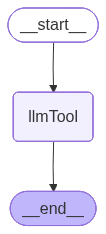

In [38]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("llmTool", llmTool)

builder.add_edge(START,"llmTool")
builder.add_edge("llmTool",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [39]:
messages = graph.invoke({"messages":"What is 3+9?"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 3+9?
================================== Ai Message ==================================
Tool Calls:
  add (fc_aabc58f0-2102-4987-bc39-9b85aed699ea)
 Call ID: fc_aabc58f0-2102-4987-bc39-9b85aed699ea
  Args:
    a: 3
    b: 9


In [41]:
tools = [add]

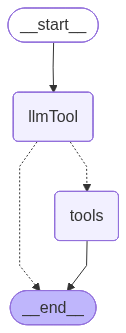

In [43]:
from langgraph.prebuilt import ToolNode, tools_condition

builder=StateGraph(State)

builder.add_node("llmTool",llmTool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llmTool")
builder.add_conditional_edges(
    "llmTool",tools_condition
)
builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
messages = graph.invoke({"messages":"What is 3+9?"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 3+9?
================================== Ai Message ==================================
Tool Calls:
  add (fc_16d82595-f06a-463b-a0fb-553e08febf31)
 Call ID: fc_16d82595-f06a-463b-a0fb-553e08febf31
  Args:
    a: 3
    b: 9
================================= Tool Message =================================
Name: add

12
